1. Understand Business Problem
          ↓
2. Load Data
          ↓
3. Data Understanding (EDA)
          ↓
4. Data Cleaning
          ↓
5. Data Preprocessing
          ↓
6. Feature Engineering
          ↓
7. Feature Selection
          ↓
8. Define X and y
          ↓
9. Train-Test Split
          ↓
10. Model Selection
          ↓
11. Model Training
          ↓
12. Model Evaluation
          ↓
13. Hyperparameter Tuning
          ↓
14. Save Model
          ↓
15. Deploy Model
          ↓
16. Monitor Model

# IBM HR Analytics Employee Attrition & Performance

Predict attrition of your valuable employees

In [140]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Step 1 : Load Data

In [141]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [142]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 2 : Understand the Data Set

**Check Null and duplicate values and eliminate them**

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [144]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [145]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [146]:
df.duplicated().sum()

0

In [147]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [148]:
df.shape

(1470, 35)

In [149]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [304]:
df['Attrition'].value_counts()  # Imbalance data

Attrition
0    1233
1     237
Name: count, dtype: int64

Check the target x Columns to understand better

In [151]:
pd.crosstab(
    df['OverTime'],
    df['Attrition']
)

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


<Axes: xlabel='Attrition', ylabel='Age'>

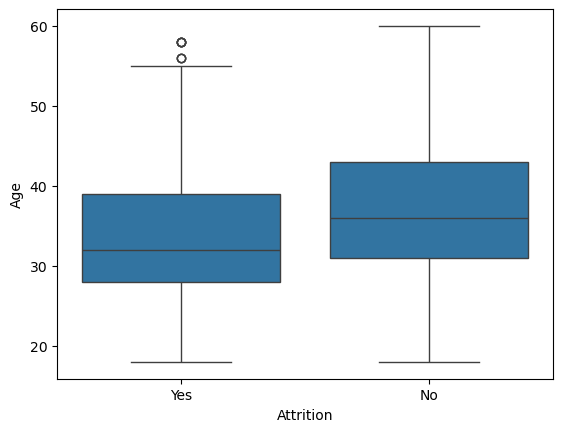

In [152]:
sns.boxplot(
    x='Attrition',
    y='Age',
    data=df
)

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

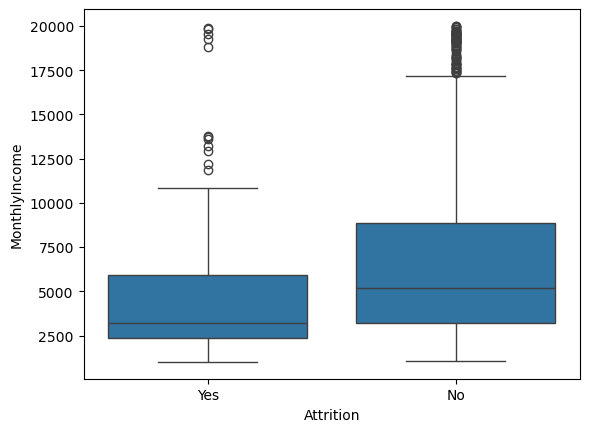

In [153]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

## Feature Engineering

In [155]:
df['AnnualIncome'] = df['MonthlyIncome'] * 12

df['AnnualIncome']

0        71916
1        61560
2        25080
3        34908
4        41616
         ...  
1465     30852
1466    119892
1467     73704
1468     64680
1469     52848
Name: AnnualIncome, Length: 1470, dtype: int64

In [156]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,60]
)

In [157]:
df['TotalSatisfaction'] = (
    df['JobSatisfaction']
    + df['EnvironmentSatisfaction']
    + df['RelationshipSatisfaction']
)

## Feature Selection

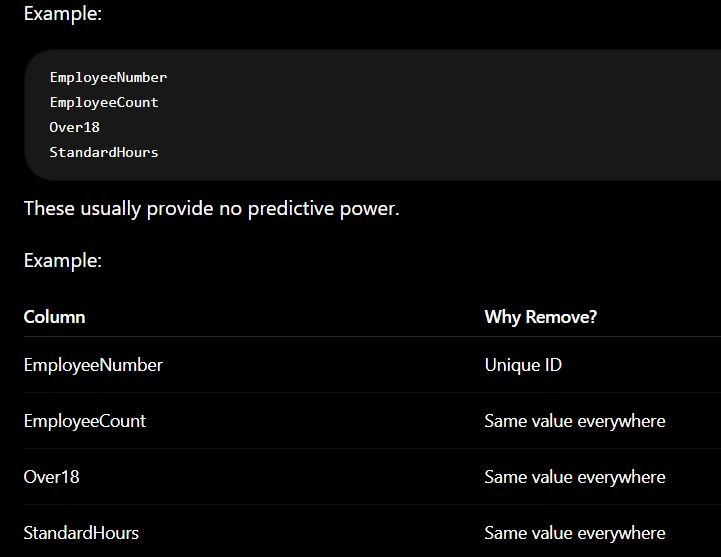

In [160]:
for col in df.columns:
    print(col, df[col].nunique())

Age 43
Attrition 2
BusinessTravel 3
DailyRate 886
Department 3
DistanceFromHome 29
Education 5
EducationField 6
EmployeeCount 1
EmployeeNumber 1470
EnvironmentSatisfaction 4
Gender 2
HourlyRate 71
JobInvolvement 4
JobLevel 5
JobRole 9
JobSatisfaction 4
MaritalStatus 3
MonthlyIncome 1349
MonthlyRate 1427
NumCompaniesWorked 10
Over18 1
OverTime 2
PercentSalaryHike 15
PerformanceRating 2
RelationshipSatisfaction 4
StandardHours 1
StockOptionLevel 4
TotalWorkingYears 40
TrainingTimesLastYear 7
WorkLifeBalance 4
YearsAtCompany 37
YearsInCurrentRole 19
YearsSinceLastPromotion 16
YearsWithCurrManager 18
AnnualIncome 1349
AgeGroup 4
TotalSatisfaction 10


From above, EmployeeCount, Over18 ,StandardHours is 1,so it says there are no unique values, so we can drop it

In [162]:
df.drop(['EmployeeCount','Over18' ,'StandardHours'] , axis=1,inplace=True)

## Encoding

In [164]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Attrition'] = le.fit_transform(df['Attrition'])

In [187]:
pd.get_dummies(df, columns=['BusinessTravel'],dtype=int)

,Age,Attrition,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AnnualIncome,AgeGroup,TotalSatisfaction,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,1,1102,Sales,1,2,Life Sciences,1,2,Female,...,6,4,0,5,71916,"(40, 50]",7,0,0,1
1,49,0,279,Research & Development,8,1,Life Sciences,2,3,Male,...,10,7,1,7,61560,"(40, 50]",9,0,1,0
2,37,1,1373,Research & Development,2,2,Other,4,4,Male,...,0,0,0,0,25080,"(30, 40]",9,0,0,1
3,33,0,1392,Research & Development,3,4,Life Sciences,5,4,Female,...,8,7,3,0,34908,"(30, 40]",10,0,1,0
4,27,0,591,Research & Development,2,1,Medical,7,1,Male,...,2,2,2,2,41616,"(18, 30]",7,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,Research & Development,23,2,Medical,2061,3,Male,...,5,2,0,3,30852,"(30, 40]",10,0,1,0
1466,39,0,613,Research & Development,6,1,Medical,2062,4,Male,...,7,7,1,7,119892,"(30, 40]",6,0,0,1
1467,27,0,155,Research & Development,4,3,Life Sciences,2064,2,Male,...,6,2,0,3,73704,"(18, 30]",6,0,0,1
1468,49,0,1023,Sales,2,3,Medical,2065,4,Male,...,9,6,0,8,64680,"(40, 50]",10,0,1,0


In [311]:
X = df.drop('Attrition', axis=1)
X = pd.get_dummies(X,drop_first=True,dtype=int)

In [313]:
X

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,"AgeGroup_(30, 40]","AgeGroup_(40, 50]","AgeGroup_(50, 60]"
0,41,1102,1,2,1,2,94,3,2,4,...,0,0,1,0,0,1,1,0,1,0
1,49,279,8,1,2,3,61,2,2,2,...,0,1,0,0,1,0,0,0,1,0
2,37,1373,2,2,4,4,92,2,1,3,...,0,0,0,0,0,1,1,1,0,0
3,33,1392,3,4,5,4,56,3,1,3,...,0,1,0,0,1,0,1,1,0,0
4,27,591,2,1,7,1,40,3,1,2,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,2061,3,41,4,2,4,...,0,0,0,0,1,0,0,1,0,0
1466,39,613,6,1,2062,4,42,2,3,1,...,0,0,0,0,1,0,0,1,0,0
1467,27,155,4,3,2064,2,87,4,2,2,...,0,0,0,0,1,0,1,0,0,0
1468,49,1023,2,3,2065,4,63,2,2,2,...,0,0,1,0,1,0,0,0,1,0


In [315]:
y = df['Attrition']

## Split to Test AND Train

In [317]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# attrition is imbalenced so we are using stratify

## Model Selection

In [320]:
# Since target is Yes/No:

# Classification algorithms.

In [322]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [324]:
# 1. LogisticRegression

from sklearn.linear_model import LogisticRegression

reg = LogisticRegression(max_iter=1000)

reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)

C:\Users\vilas\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [325]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print(f"Accuracy : {accuracy:.2f}")

Accuracy : 0.85


In [328]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.67      0.09      0.15        47

    accuracy                           0.85       294
   macro avg       0.76      0.54      0.53       294
weighted avg       0.82      0.85      0.79       294



In [330]:
# 2. Decision Tree

from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()

DT.fit(X_train,y_train)

y_pred = DT.predict(X_test)

In [332]:
accuracy = accuracy_score(y_test,y_pred)

print(f"Accuracy : {accuracy:.2f}")

Accuracy : 0.78


In [334]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       247
           1       0.33      0.36      0.35        47

    accuracy                           0.78       294
   macro avg       0.60      0.61      0.61       294
weighted avg       0.79      0.78      0.79       294



In [336]:
# 3. Random Forest

from sklearn.ensemble import RandomForestClassifier

RD = RandomForestClassifier( n_estimators=100, random_state=42)

RD.fit(X_train,y_train)

y_pred = RD.predict(X_test)

In [337]:
accuracy = accuracy_score(y_test,y_pred)

print(f"Accuracy : {accuracy:.2f}")

Accuracy : 0.84


In [338]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



## Comparing Models 

In [340]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)

    print(f'{name}, {score:.2f}')

C:\Users\vilas\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic, 0.85
Decision Tree, 0.78
Random Forest, 0.84


In [341]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

importance = model.feature_importances_

In [342]:
for col, imp in zip(X.columns, importance):
    if imp > 0.04:
        print(f'{col}: {imp*1000:.2f}%')

Age: 51.72%
DailyRate: 45.81%
EmployeeNumber: 40.30%
MonthlyIncome: 58.02%
MonthlyRate: 42.85%
TotalWorkingYears: 46.27%
AnnualIncome: 58.32%


In [343]:
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.round(importance*1000,2)
})

feature_imp.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
24,AnnualIncome,58.32
10,MonthlyIncome,58.02
0,Age,51.72
17,TotalWorkingYears,46.27
1,DailyRate,45.81
11,MonthlyRate,42.85
4,EmployeeNumber,40.30
2,DistanceFromHome,39.81
6,HourlyRate,39.51
20,YearsAtCompany,39.10
